# Use hormone2cell to predict hormone producing/receiving cell types.

This notebook showcases how to predict hormone producing cell types using hormone2cell.

**Steps**:
- 0. **Download and process the dataset**
     

- 1. **Calculate average expression per cell type per tissue**
     - Calculate the average gene expression for each cell type within each tissue.
- 2. **Predict hormone producing strength**
  - 2.1 Identify hormone-producing cell types using data-derived thresholds.
  - 2.2 Identify hormone-producing cell types using precomputed thresholds from the Hormone Cell Atlas.
  - Notes:
    - The precomputed thresholds are derived from the pan-tissue Hormone Cell Atlas, while the data-derived thresholds are calculated directly from the user-provided dataset. Depending on your analytical goals, you may choose either 2.1 (data-derived) or 2.2 (precomputed).
    - Without adjustment: Predictions of hormone-producing cell types and their strengths are made directly using the default function `hormone_strength`, without applying any adjustment to gene expression thresholds.
    - With adjustment: Predictions of hormone-producing cell types and their strengths are performed using the `hormone_strength` function with `adjustment =  True`. Here, adjustment refers to modifying thresholds for hormone-related genes based on the overall specificity score and the degree of tissue coverage.
    - When both single-cell and single-nucleus data are available, predictions should be performed separately for each dataset, because expression levels can differ substantially due to gene length (Lake et al., 2017: https://www.nature.com/articles/s41598-017-04426-w
). The results can then be integrated by taking the maximum strength observed across the two assays.    
- 3. **Predict hormone receiving strength**
  - 3.1 Identify hormone-receiving cell types using data-derived thresholds.
  - 3.2 Identify hormone-receiving cell types using precomputed thresholds from the Hormone Cell Atlas.
  - Notes:
     - It is recommended not to adjust the thresholds for hormone-receiving-related genes, since hormone sensitization is generally broader than hormone production.
    



In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import time
from collections import Counter
import hormone2cell

import matplotlib.pyplot as plt
from matplotlib_venn import venn2

In [2]:
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.set_figure_params(dpi=80, facecolor="white")
#sc.logging.print_header()

## 0. Download and process the dataset

We used the pancreas as the query dataset, which includes both single-cell and single-nucleus data. The dataset was downloaded from the CellxGene website (https://datasets.cellxgene.cziscience.com/d7191e85-30c6-41ba-a439-e1d1fe5a3227.h5ad). For demonstration purposes, we sampled 200 cells per cell type per suspension type.

If you would like to reproduce the hormone-producing and hormone-receiving results from our manuscript, please download the per-tissue h5ad files from https://hormonecellatlas.org.uk/downloads/
 and run the analysis using the precomputed thresholds provided by the Hormone Cell Atlas.

In [3]:
# adata=sc.read('data/pancreas_downsample200CT.h5ad')
adata=hormone2cell.data.load_pancreas_data()

In [4]:
adata.shape

(3274, 33053)

Raw count data with the full gene set are required for hormone2cell.

In [5]:
adata=adata.raw.to_adata()

In [6]:
adata.X.data.max()

np.float32(450742.0)

Check and modify the obs to meet the requirements of hormone2cell. The `.obs` must contain columns for the tissue, cell type and suspension type (i.e. cell or nucleus) for downstream analysis.

In [7]:
adata.obs['suspension_type'].value_counts()

suspension_type
nucleus    1674
cell       1600
Name: count, dtype: int64

In [8]:
adata.obs['cell_type'].value_counts()

cell_type
endothelial cell            400
pancreatic A cell           400
pancreatic D cell           400
pancreatic ductal cell      400
pancreatic acinar cell      400
pancreatic stellate cell    400
type B pancreatic cell      400
pancreatic PP cell          274
macrophage                  200
Name: count, dtype: int64

In [9]:
adata.obs['Tissue']='Pancreas'

Ensure that `.var_names` are gene symbols, this particular object comes with them set to ENSG IDs.

In [10]:
adata.var['gene_id']=adata.var.index
adata.var['feature_name']=adata.var['feature_name'].astype('str')
adata.var = adata.var.set_index('feature_name')
adata.var_names_make_unique()
adata.var.head(2)

,exist_in_Tritschler2022,exist_in_Fasolino2022,exist_in_Muraro2016,exist_in_Tosti2021,feature_reference,feature_biotype,feature_length,feature_type,gene_id
feature_name,,,,,,,,,
A1BG,True,True,True,True,NCBITaxon:9606,gene,2134,protein_coding,ENSG00000121410
A1BG-AS1,True,True,True,True,NCBITaxon:9606,gene,1667,lncRNA,ENSG00000268895


## 1. Calculate average expression per cell type per tissue

Along with the actual average expression, which is computed after internally running `sc.pp.normalize_total()` with a target sum of 10,000 and log1p-transformed prior to being returned, the resulting data frame carries additional information on the gene's presence in any given tissue/celltype/suspension combination which is used in downstream analysis.

In [11]:
ave_all=hormone2cell.compute_aveExp_by_category(adata,sc_sn_col='suspension_type',
                                                celltype_col= "cell_type",
                                               tissue_col='Tissue')

363 hormone-related genes are found.
normalizing counts per cell


/rfs/project/rfs-iCNyzSAaucw/lf529/miniforge3/envs/hormone2cell_env2/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


    finished (0:00:02)
Computing average gene expression per cell type in the cell dataset.
filtered out 130 genes that are detected in less than 3 cells
Tissues in input: ['Pancreas'] — average calculation done.
Computing average gene expression per cell type in the nucleus dataset.
filtered out 125 genes that are detected in less than 3 cells
Tissues in input: ['Pancreas'] — average calculation done.


/rfs/project/rfs-iCNyzSAaucw/lf529/miniforge3/envs/hormone2cell_env2/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:88: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


In [12]:
ave_all.head(2)

,Tissue,cell_type,Cluster,Celltype_tissue,Gene,ExpressedCellNumber,TotalCellNumber,Percentage,logExpression,suspension_type
1,Pancreas,pancreatic A cell,2,Pancreas____pancreatic A cell,IGF2,13,200,6.5,0.732021,cell
2,Pancreas,pancreatic D cell,3,Pancreas____pancreatic D cell,IGF2,24,200,12.0,0.668118,cell


In [13]:
ave_all.shape

(2822, 10)

## 2. Predict hormone producing strength

Load the definitions of hormone production, as specified in the hormone–receptor reference database of the Hormone Cell Atlas project.

In this dataframe, `hormogene_include` columns represent genes involved in the induction of hormone production, while `hormogene_exclude` columns represent genes involved in its repression. The columns represent an `AND` relationship, i.e. all of the genes in a row need to fulfil subsequent filtering conditions for the hormone to qualify as produced or repressed in a cell type. `OR` relationships, indicative of multiple independent production pathways, are represented by multiple entries for the hormone in the data frame.


Genes excluded from strength calculations but required to meet expression thresholds are hard-coded in utils.py (see Methods in Fei & Huang-Doran (in press)) and may you need to adjust these definitions for your own study.

In [14]:
hormone_definition=hormone2cell.data.load_hormone_producing_file()
hormone_definition.head(2)

,hormone_short,hormone_display,hormone_figures,Tier,hpc_include1,hpc_include2,hpc_include3,hpc_include4,hpc_include5,hpc_include6,hpc_include7,hpc_include8,hpc_exclude1,hpc_exclude2,receptor_known,hormone_type_broad,hormone_type_fine
0,acth,ACTH,ACTH,1,POMC,PCSK1,NaN,NaN,NaN,NaN,NaN,NaN,PCSK2,NaN,yes,peptide_protein,peptide
1,activin_a,Activin A,Activin A,2,INHBA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,peptide_protein,protein_multimer


### 2.1 Identify hormone-producing cell types using data-derived thresholds.

At this point, we're ready to perform data-driven hormone2cell inference. The function will:
- Filter the average expression data frame, removing entries with fewer than 10 cells in a category, fewer than 3 cells expressing the gene, or where the log expression is too low (`thresh_expr_low`) or has too low a percentage of expressing cells (`thresh_pct`).
- For each gene, identify its highest observed expression in a cell type across the whole data.
- For genes inducing hormone production (`include_cols` from the loaded hormone definition data frame), require at least `thresh_included_initial` of the max expression to be kept in the expression matrix. For values below that threshold, the expression will be set to 0.
- For genes repressing hormone production (`exclude_cols`), require at least `thresh_excluded_initial` of the max expression to be kept in the expression matrix. For values below that threshold, the expression will be set to 0.
- For a hormone to be deemed present in a cell type, any of its independent induction mechanisms (individual lines in the reference data frame, OR logic) must be fulfilled. An induction mechanism is deemed fulfilled if all of its induction genes have nonzero expression after the filtering (AND logic). Any induction gene having zero expression, or all repression genes having nonzero expression, has the induction mechanism set to not fulfilled.
- Hormone activity is screened for specificity. If hormone production is present in at least `coverage_threshold` of the cell types of a tissue, or a Tau specificty score below `specificity_threshold` (with the input computed as the mean expression of a hormone's AND genes, summed up across its OR induction mechanisms, for instances of hormone production being considered active in a cell type; 0 otherwise), the hormone is deemed to be non-specific. Causes of this may include ambient RNA contamination.
- For non-specific hormones, the expression filtering thresholds are adjusted to `thresh_included_adjusted` and `thresh_excluded_adjusted` and the analysis is repeated.

In [20]:
ave_all.head()

,Tissue,cell_type,Cluster,Celltype_tissue,Gene,ExpressedCellNumber,TotalCellNumber,Percentage,logExpression,suspension_type
1,Pancreas,pancreatic A cell,2,Pancreas____pancreatic A cell,IGF2,13,200,6.5,0.732021,cell
2,Pancreas,pancreatic D cell,3,Pancreas____pancreatic D cell,IGF2,24,200,12.0,0.668118,cell
3,Pancreas,pancreatic PP cell,4,Pancreas____pancreatic PP cell,IGF2,4,200,2.0,0.246472,cell
5,Pancreas,pancreatic ductal cell,6,Pancreas____pancreatic ductal cell,IGF2,2,200,1.0,0.092293,cell
7,Pancreas,type B pancreatic cell,8,Pancreas____type B pancreatic cell,IGF2,114,200,57.0,1.943938,cell


In [22]:
%%time
mask=ave_all['suspension_type']=='cell'
ave_all_cell=ave_all.loc[mask]
dt_cell=hormone2cell.hormone_strength(
    ave_all = ave_all_cell,
    geneset_definition = hormone_definition,
    celltype_column = "Celltype_tissue",
    tissue_col = "Tissue",
    adjustment =  True,
    assay = "cell",
    include_cols = ['hpc_include1', 'hpc_include2', 'hpc_include3',
       'hpc_include4', 'hpc_include5', 'hpc_include6', 'hpc_include7',
       'hpc_include8'],
    exclude_cols =['hpc_exclude1', 'hpc_exclude2'],
    # initial thresholds
    thresh_expr_low = 0.01,
    thresh_pct = 5,
    # specificity / coverage thresholds
    specificity_threshold = 0.8,
    coverage_threshold = 0.5,
    # filtering thresholds (first pass)
    thresh_included_initial = 0.1,
    thresh_excluded_initial = 0.15,
    # filtering thresholds (adjusted pass)
    thresh_included_adjusted = 0.5,
    thresh_excluded_adjusted = 0.15,
    max_expression_file='max_expression_cell.csv'
)
dt_cell.shape

I. Compute initial strengths
    1) Filter the input expression table
    2) Build gene–celltype matrix for included genes (lower threshold)
            Use Max_logExp from current data
    3) Build gene–celltype matrix for excluded genes (higher threshold)
            Use Max_logExp from current data
    4) Apply hormone rules to compute the final table
II. Identify hormones to adjust and recompute only the adjusted hormones
   1). Identify hormones to adjust based on the specificity
    1) Filter the input expression table
    2) Build gene–celltype matrix for included genes (lower threshold)
            Use Max_logExp from current data
    3) Build gene–celltype matrix for excluded genes (higher threshold)
            Use Max_logExp from current data
    4) Apply hormone rules to compute the final table
   2). Identify hormones to adjust based on the tissue coverage
    1) Filter the input expression table
    2) Build gene–celltype matrix for included genes (lower threshold)
      

(173, 8)

The resulted `dt_cell` contains the hormones expressed in each cell type and their expression strengths, along with the corresponding annotations.

In [23]:
dt_cell.head(2)

,Hormone,Celltype_tissue,Strength,Tissue,hormone_display,hormone_short,Tier,assay
0,glp1,Pancreas____pancreatic stellate cell,7.070757,Pancreas,Glucagon-like peptide 1,glp1,2,cell
1,glp1,Pancreas____type B pancreatic cell,5.734788,Pancreas,Glucagon-like peptide 1,glp1,2,cell


We can perform the analysis on nuclear rather than cellular data as well.

In [24]:
mask=ave_all['suspension_type']=='nucleus'
ave_all_nucleus=ave_all.loc[mask]
dt_nucleus=hormone2cell.hormone_strength(
    ave_all = ave_all_nucleus,
    geneset_definition = hormone_definition,
    celltype_column = "Celltype_tissue",
    tissue_col = "Tissue",
    adjustment =  True,
    assay = "nucleus",
    include_cols = ['hpc_include1', 'hpc_include2', 'hpc_include3',
       'hpc_include4', 'hpc_include5', 'hpc_include6', 'hpc_include7',
       'hpc_include8'],
    exclude_cols =['hpc_exclude1', 'hpc_exclude2'],
    # initial thresholds
    thresh_expr_low = 0.01,
    thresh_pct = 5,
    # specificity / coverage thresholds
    specificity_threshold = 0.8,
    coverage_threshold = 0.5,
    # filtering thresholds (first pass)
    thresh_included_initial = 0.1,
    thresh_excluded_initial = 0.15,
    # filtering thresholds (adjusted pass)
    thresh_included_adjusted = 0.5,
    thresh_excluded_adjusted = 0.15,
    max_expression_file='max_expression_nucleus.csv'
)

I. Compute initial strengths
    1) Filter the input expression table
    2) Build gene–celltype matrix for included genes (lower threshold)
            Use Max_logExp from current data
    3) Build gene–celltype matrix for excluded genes (higher threshold)
            Use Max_logExp from current data
    4) Apply hormone rules to compute the final table
II. Identify hormones to adjust and recompute only the adjusted hormones
   1). Identify hormones to adjust based on the specificity
    1) Filter the input expression table
    2) Build gene–celltype matrix for included genes (lower threshold)
            Use Max_logExp from current data
    3) Build gene–celltype matrix for excluded genes (higher threshold)
            Use Max_logExp from current data
    4) Apply hormone rules to compute the final table
   2). Identify hormones to adjust based on the tissue coverage
    1) Filter the input expression table
    2) Build gene–celltype matrix for included genes (lower threshold)
      

In [25]:
dt_nucleus.head(2)

,Hormone,Celltype_tissue,Strength,Tissue,hormone_display,hormone_short,Tier,assay
0,crh,Pancreas____pancreatic D cell,2.320317,Pancreas,CRH,crh,1,nucleus
2,somatostatin,Pancreas____pancreatic D cell,8.120015,Pancreas,Somatostatin,somatostatin,2,nucleus


#### 2.1.1 Combine results from single cell and single nucleus data.

In [26]:
hpc_datadriven=hormone2cell.combine_assay(cell=dt_cell, nucleus=dt_nucleus,celltype_column='Celltype_tissue')
display(hpc_datadriven.head(2))
hpc_datadriven.shape

,Hormone,Celltype_tissue,Strength,Tissue,hormone_display,hormone_short,Tier,assay,Hormone_CT
0,glp1,Pancreas____pancreatic stellate cell,7.070757,Pancreas,Glucagon-like peptide 1,glp1,2,cell_only,glp1___Pancreas____pancreatic stellate cell
1,glp1,Pancreas____pancreatic PP cell,4.827841,Pancreas,Glucagon-like peptide 1,glp1,2,cell_only,glp1___Pancreas____pancreatic PP cell


(188, 9)

### 2.2 Identify hormone-producing cell types using precomputed thresholds from the Hormone Cell Atlas.
A key strength of the accompanying manuscript is its analysis of a large integrated dataset spanning 47 tissues and 14 million cells. The large scale integration allowed for defining maximum values in a manner more representative of what is likely to be occurring at the level of the entire body, which should lead to more informed thresholding.

In [27]:
%%time
mask=ave_all['suspension_type']=='cell'
ave_all_cell=ave_all.loc[mask]
dt_cell=hormone2cell.hormone_strength(
    ave_all = ave_all_cell,
    geneset_definition = hormone_definition,
    celltype_column = "Celltype_tissue",
    tissue_col = "Tissue",
    adjustment =  True,
    assay = "cell",
    include_cols = ['hpc_include1', 'hpc_include2', 'hpc_include3',
       'hpc_include4', 'hpc_include5', 'hpc_include6', 'hpc_include7',
       'hpc_include8'],
    exclude_cols =['hpc_exclude1', 'hpc_exclude2'],
    # initial thresholds
    thresh_expr_low = 0.01,
    thresh_pct = 5,
    # specificity / coverage thresholds
    specificity_threshold = 0.8,
    coverage_threshold = 0.5,
    # filtering thresholds (first pass)
    thresh_included_initial = 0.1,
    thresh_excluded_initial = 0.15,
    # filtering thresholds (adjusted pass)
    thresh_included_adjusted = 0.5,
    thresh_excluded_adjusted = 0.15,
    use_precomputed='cell',
    max_expression_file='max_expression_cell_pre.csv'
)
dt_cell.shape

I. Compute initial strengths
    1) Filter the input expression table
    2) Build gene–celltype matrix for included genes (lower threshold)
            Use Max_logExp from precomputed data
    3) Build gene–celltype matrix for excluded genes (higher threshold)
            Use Max_logExp from precomputed data
    4) Apply hormone rules to compute the final table
II. Identify hormones to adjust and recompute only the adjusted hormones
   1). Identify hormones to adjust based on the specificity
    1) Filter the input expression table
    2) Build gene–celltype matrix for included genes (lower threshold)
            Use Max_logExp from precomputed data
    3) Build gene–celltype matrix for excluded genes (higher threshold)
            Use Max_logExp from precomputed data
    4) Apply hormone rules to compute the final table
   2). Identify hormones to adjust based on the tissue coverage
    1) Filter the input expression table
    2) Build gene–celltype matrix for included genes (lower t

(194, 8)

In [28]:
mask=ave_all['suspension_type']=='nucleus'
ave_all_nucleus=ave_all.loc[mask]
dt_nucleus=hormone2cell.hormone_strength(
    ave_all = ave_all_nucleus,
    geneset_definition = hormone_definition,
    celltype_column = "Celltype_tissue",
    tissue_col = "Tissue",
    adjustment =  True,
    assay = "nucleus",
    include_cols = ['hpc_include1', 'hpc_include2', 'hpc_include3',
       'hpc_include4', 'hpc_include5', 'hpc_include6', 'hpc_include7',
       'hpc_include8'],
    exclude_cols =['hpc_exclude1', 'hpc_exclude2'],
    # initial thresholds
    thresh_expr_low = 0.01,
    thresh_pct = 5,
    # specificity / coverage thresholds
    specificity_threshold = 0.8,
    coverage_threshold = 0.5,
    # filtering thresholds (first pass)
    thresh_included_initial = 0.1,
    thresh_excluded_initial = 0.15,
    # filtering thresholds (adjusted pass)
    thresh_included_adjusted = 0.5,
    thresh_excluded_adjusted = 0.15,
    use_precomputed='nucleus',
    max_expression_file='max_expression_nucleus_pre.csv'
)
dt_nucleus.shape

I. Compute initial strengths
    1) Filter the input expression table
    2) Build gene–celltype matrix for included genes (lower threshold)
            Use Max_logExp from precomputed data
    3) Build gene–celltype matrix for excluded genes (higher threshold)
            Use Max_logExp from precomputed data
    4) Apply hormone rules to compute the final table
II. Identify hormones to adjust and recompute only the adjusted hormones
   1). Identify hormones to adjust based on the specificity
    1) Filter the input expression table
    2) Build gene–celltype matrix for included genes (lower threshold)
            Use Max_logExp from precomputed data
    3) Build gene–celltype matrix for excluded genes (higher threshold)
            Use Max_logExp from precomputed data
    4) Apply hormone rules to compute the final table
   2). Identify hormones to adjust based on the tissue coverage
    1) Filter the input expression table
    2) Build gene–celltype matrix for included genes (lower t

(76, 8)

#### 2.2.1 Combine results from single cell and single nucleus data.

In [29]:
hpc_precomputed=hormone2cell.combine_assay(cell=dt_cell, nucleus=dt_nucleus,celltype_column='Celltype_tissue')
display(hpc_datadriven.head(2))
hpc_precomputed.shape

,Hormone,Celltype_tissue,Strength,Tissue,hormone_display,hormone_short,Tier,assay,Hormone_CT
0,glp1,Pancreas____pancreatic stellate cell,7.070757,Pancreas,Glucagon-like peptide 1,glp1,2,cell_only,glp1___Pancreas____pancreatic stellate cell
1,glp1,Pancreas____pancreatic PP cell,4.827841,Pancreas,Glucagon-like peptide 1,glp1,2,cell_only,glp1___Pancreas____pancreatic PP cell


(208, 9)

Visulization of the hormone producing cell types from two methods.

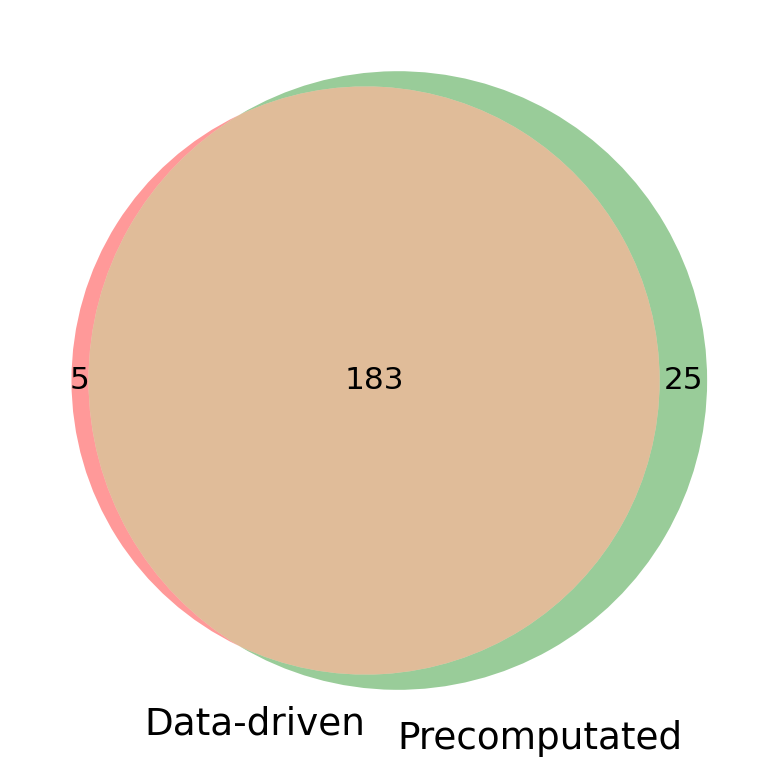

In [30]:
# import matplotlib.pyplot as plt
# from matplotlib_venn import venn2

set1 = set(hpc_datadriven['Hormone_CT'])
set2 = set(hpc_precomputed['Hormone_CT'])

plt.figure(figsize=(6,6))
venn2([set1, set2], set_labels=("Data-driven", "Precomputated"))
plt.show()

In [31]:
## save the files if needed
# hpc_datadriven.to_csv('hpc_datadriven.csv')
# hpc_precomputed.to_csv('hpc_precomputed.csv')

## 3. Predict hormone receiving strength

Load the hormone receiving definitions from the hormone-receptor reference database. The file is formatted similarly to the earlier one, the pertinent columns being `receptorgene` this time.

Genes excluded from strength calculations but required to meet expression thresholds are hard-coded in utils.py (see Methods in Fei & Huang-Doran (in press)) and may you need to adjust these definitions for your own study.

In [32]:
receptor_definition=hormone2cell.data.load_hormone_receptor_file()
receptor_definition.head(2)

,hormone_short,hormone_display,hormone_figures,Tier,receptorgene1,receptorgene2,gene1_name,gene2_name,receptor_type_broad,receptor_type_fine,receptor_status
0,asprosin,Asprosin,Asprosin,3,OR4M1,NaN,olfactory receptor family 4 subfamily M member 1,NaN,gpcr,NaN,established
1,asprosin,Asprosin,Asprosin,3,PTPRD,NaN,protein tyrosine phosphatase receptor delta,NaN,enzyme_linked,NaN,established


### 3.1 Identify hormone-receiving cell types using data-derived thresholds.

In [33]:
%%time
mask=ave_all['suspension_type']=='cell'
ave_all_cell=ave_all.loc[mask]
dt_cell=hormone2cell.hormone_strength(
    ave_all = ave_all_cell,
    geneset_definition = receptor_definition,
    celltype_column = "Celltype_tissue",
    tissue_col = "Tissue",
    adjustment =  False,
    assay = "cell",
    include_cols = ['receptorgene1', 'receptorgene2'],
    exclude_cols =[],
    # initial thresholds
    thresh_expr_low = 0.01,
    thresh_pct = 5,
    # filtering thresholds (first pass)
    thresh_included_initial = 0.1,
    thresh_excluded_initial = 0.15,
    max_expression_file='max_expression_cell_receptor.csv'
)
display(dt_cell.head(2))
dt_cell.shape

    1) Filter the input expression table
    2) Build gene–celltype matrix for included genes (lower threshold)
            Use Max_logExp from current data
    3) Build gene–celltype matrix for excluded genes (higher threshold)
            Use Max_logExp from current data
    4) Apply hormone rules to compute the final table
      Hormone                       Celltype_tissue   Strength    Tissue
612  resistin  Pancreas____pancreatic stellate cell  14.868078  Pancreas
52       igf2          Pancreas____endothelial cell  12.381264  Pancreas
Before removing duplicates: (837, 7)
After removing duplicates: (311, 7)
Finally hormone2cell finds: 311 hormone-celltype pairs.


,Hormone,Celltype_tissue,Strength,Tissue,hormone_display,hormone_short,Tier,assay
0,gastrin,Pancreas____pancreatic D cell,0.422587,Pancreas,Gastrin,gastrin,2,cell
1,gastrin,Pancreas____pancreatic PP cell,0.303184,Pancreas,Gastrin,gastrin,2,cell


CPU times: user 389 ms, sys: 3.74 ms, total: 392 ms
Wall time: 414 ms


(311, 8)

In [34]:
mask=ave_all['suspension_type']=='nucleus'
ave_all_nucleus=ave_all.loc[mask]
dt_nucleus=hormone2cell.hormone_strength(
    ave_all = ave_all_nucleus,
    geneset_definition = receptor_definition,
    celltype_column = "Celltype_tissue",
    tissue_col = "Tissue",
    adjustment =  False,
    assay = "cell",
    include_cols = ['receptorgene1', 'receptorgene2'],
    exclude_cols =[],
    # initial thresholds
    thresh_expr_low = 0.01,
    thresh_pct = 5,
    # filtering thresholds (first pass)
    thresh_included_initial = 0.1,
    thresh_excluded_initial = 0.15,
    max_expression_file='max_expression_nucleus_receptor.csv'
)
display(dt_cell.head(2))
dt_nucleus.shape

    1) Filter the input expression table
    2) Build gene–celltype matrix for included genes (lower threshold)
            Use Max_logExp from current data
    3) Build gene–celltype matrix for excluded genes (higher threshold)
            Use Max_logExp from current data
    4) Apply hormone rules to compute the final table
    Hormone                     Celltype_tissue   Strength    Tissue
481    igf2  Pancreas____pancreatic acinar cell  18.891066  Pancreas
568    igf2  Pancreas____pancreatic ductal cell  16.461430  Pancreas
Before removing duplicates: (744, 7)
After removing duplicates: (291, 7)
Finally hormone2cell finds: 291 hormone-celltype pairs.


,Hormone,Celltype_tissue,Strength,Tissue,hormone_display,hormone_short,Tier,assay
0,gastrin,Pancreas____pancreatic D cell,0.422587,Pancreas,Gastrin,gastrin,2,cell
1,gastrin,Pancreas____pancreatic PP cell,0.303184,Pancreas,Gastrin,gastrin,2,cell


(291, 8)

#### 3.2.1 Combine results from single cell and single nucleus data.

In [35]:
hrc_datadriven=hormone2cell.combine_assay(cell=dt_cell, nucleus=dt_nucleus,celltype_column='Celltype_tissue')
hrc_datadriven.shape

(424, 9)

### 3.2 Identify hormone-receiving cell types using precomputed thresholds from the Hormone Cell Atlas.

In [36]:
%%time
mask=ave_all['suspension_type']=='cell'
ave_all_cell=ave_all.loc[mask]
dt_cell=hormone2cell.hormone_strength(
    ave_all = ave_all_cell,
    geneset_definition = receptor_definition,
    celltype_column = "Celltype_tissue",
    tissue_col = "Tissue",
    adjustment =  False,
    assay = "cell",
    include_cols = ['receptorgene1', 'receptorgene2'],
    exclude_cols =[],
    # initial thresholds
    thresh_expr_low = 0.01,
    thresh_pct = 5,
    # filtering thresholds (first pass)
    thresh_included_initial = 0.1,
    thresh_excluded_initial = 0.15,
    use_precomputed='cell',
    max_expression_file='max_expression_cell_receptor2.csv'
)
display(dt_cell.head(2))
dt_cell.shape

    1) Filter the input expression table
    2) Build gene–celltype matrix for included genes (lower threshold)
            Use Max_logExp from precomputed data
    3) Build gene–celltype matrix for excluded genes (higher threshold)
            Use Max_logExp from precomputed data
    4) Apply hormone rules to compute the final table
      Hormone                       Celltype_tissue   Strength    Tissue
612  resistin  Pancreas____pancreatic stellate cell  14.868078  Pancreas
52       igf2          Pancreas____endothelial cell  12.381264  Pancreas
Before removing duplicates: (848, 7)
After removing duplicates: (311, 7)
Finally hormone2cell finds: 311 hormone-celltype pairs.


,Hormone,Celltype_tissue,Strength,Tissue,hormone_display,hormone_short,Tier,assay
0,gastrin,Pancreas____pancreatic D cell,0.422587,Pancreas,Gastrin,gastrin,2,cell
1,gastrin,Pancreas____pancreatic PP cell,0.303184,Pancreas,Gastrin,gastrin,2,cell


CPU times: user 390 ms, sys: 2.1 ms, total: 392 ms
Wall time: 394 ms


(311, 8)

In [37]:
mask=ave_all['suspension_type']=='nucleus'
ave_all_nucleus=ave_all.loc[mask]
dt_nucleus=hormone2cell.hormone_strength(
    ave_all = ave_all_nucleus,
    geneset_definition = receptor_definition,
    celltype_column = "Celltype_tissue",
    tissue_col = "Tissue",
    adjustment =  False,
    assay = "nucleus",
    include_cols = ['receptorgene1', 'receptorgene2'],
    exclude_cols =[],
    # initial thresholds
    thresh_expr_low = 0.01,
    thresh_pct = 5,
    # filtering thresholds (first pass)
    thresh_included_initial = 0.1,
    thresh_excluded_initial = 0.15,
    use_precomputed='nucleus',
    max_expression_file='max_expression_nucleus_receptor2.csv'
)
display(dt_nucleus.head(2))
dt_nucleus.shape

    1) Filter the input expression table
    2) Build gene–celltype matrix for included genes (lower threshold)
            Use Max_logExp from precomputed data
    3) Build gene–celltype matrix for excluded genes (higher threshold)
            Use Max_logExp from precomputed data
    4) Apply hormone rules to compute the final table
    Hormone                     Celltype_tissue   Strength    Tissue
481    igf2  Pancreas____pancreatic acinar cell  18.891066  Pancreas
568    igf2  Pancreas____pancreatic ductal cell  16.461430  Pancreas
Before removing duplicates: (744, 7)
After removing duplicates: (291, 7)
Finally hormone2cell finds: 291 hormone-celltype pairs.


,Hormone,Celltype_tissue,Strength,Tissue,hormone_display,hormone_short,Tier,assay
0,gastrin,Pancreas____pancreatic acinar cell,5.188416,Pancreas,Gastrin,gastrin,2,nucleus
1,insulin,Pancreas____pancreatic acinar cell,7.339443,Pancreas,Insulin,insulin,1,nucleus


(291, 8)

#### 3.2.1 Combine results from single cell and single nucleus data.

In [38]:
hrc_precomputed=hormone2cell.combine_assay(cell=dt_cell, nucleus=dt_nucleus,celltype_column='Celltype_tissue')
hrc_precomputed.shape

(427, 9)

Visulization of the hormone producing cell types from two methods.

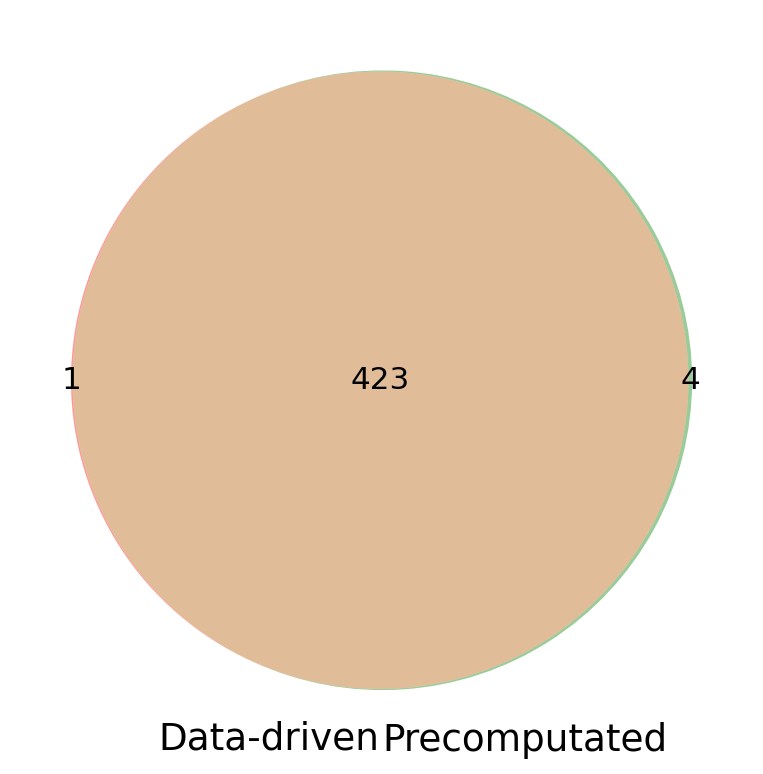

In [39]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn3

set1 = set(hrc_datadriven['Hormone_CT'])
set2 = set(hrc_precomputed['Hormone_CT'])

plt.figure(figsize=(6,6))
venn2([set1, set2], set_labels=("Data-driven", "Precomputated"))
plt.show()

In [40]:
# hrc_datadriven.to_csv('hrc_datadriven.csv')
# hrc_precomputed.to_csv('hrc_precomputed.csv')